# Bias in Chicago Food Inspection Models

This notebook is about bias in food inspection models across Chicago. It starts with the raw city data and ends with a machine learning model that predicts which restaurant inspections will turn up a critical health violation.

Along the way it shows how the data was pulled and cleaned, how the features were built, and how three different models perform on the same prediction task. Then the winning model gets scored inside three kinds of Chicago neighborhoods and a real gap turns up. Some neighborhoods get caught less often than others when a real violation is present. That gap is bias, and the second half of this notebook tries to shrink it.

Two fixes are tested, each one drawn from a published paper. Every fix is checked against the same metrics so the results are comparable, and every claim in this notebook is backed by a number that the code actually produced.


## Data

The project pulls from six City of Chicago data feeds, plus one weather feed. Food Inspections sits at the center, since every row becomes one prediction. Business Licenses shows how old a restaurant is and what other licenses it holds. Crime, garbage cart requests, and sanitation complaints describe the neighborhood around each inspection. Weather adds recent temperature and rain.

The original version of this project used data from 2011 through 2014. This version was pointed at 2018 onward, so it reflects the city today. In the meantime the city changed its data portal, and every column name switched to lowercase. The download scripts carry a small patch that renames each lowercase column back to the name the rest of the pipeline expects, so old code keeps working on new data. Two of the feeds, garbage carts and sanitation complaints, were also folded into one general 311 service years ago, so those scripts point at the merged feed and filter by request type.

The cell below lists each feed with its file size, then peeks at a few rows of the food inspections feed without loading the whole file.


In [1]:
import os
from IPython.display import display, Image
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

feeds = {
    "11_bus_license.csv": "Business Licenses",
    "12_crime.csv": "Crimes, burglary only",
    "13_food_inspections.csv": "Food Inspections",
    "14_garbage_carts.csv": "311 Garbage Cart Maintenance",
    "15_sanitation_code.csv": "311 Sanitation Code Violation",
    "17_mongo_weather_update.csv": "Daily weather at O'Hare",
}
rows = []
for fname, desc in feeds.items():
    size_mb = os.path.getsize(f"../../data/{fname}") / 1e6
    rows.append({"file": fname, "feed": desc, "size mb": round(size_mb, 1)})
display(pd.DataFrame(rows))

peek = pd.read_csv("../../data/13_food_inspections.csv", nrows=3)
peek[["Inspection_ID", "DBA_Name", "Facility_Type", "Inspection_Date", "Inspection_Type", "Results"]]


,file,feed,size mb
0,11_bus_license.csv,Business Licenses,110.8
1,12_crime.csv,"Crimes, burglary only",16.2
2,13_food_inspections.csv,Food Inspections,163.7
3,14_garbage_carts.csv,311 Garbage Cart Maintenance,128.1
4,15_sanitation_code.csv,311 Sanitation Code Violation,37.3
5,17_mongo_weather_update.csv,Daily weather at O'Hare,0.1


,Inspection_ID,DBA_Name,Facility_Type,Inspection_Date,Inspection_Type,Results
0,2608427,NORTH LAWNDALE YMCA,Daycare Above and Under 2 Years,2024-12-04,Canvass,Pass
1,2608429,LEGENDS CHICKEN & FISH CAFE,Restaurant,2024-12-04,Canvass Re-Inspection,Pass
2,2608403,AAA MAXWELL STREET EXPRESS,Restaurant,2024-12-04,Complaint,Fail


Not every row in the raw feed belongs in the model. The cleaning step keeps only Canvass inspections, which are routine visits, and drops Complaint or other visit types, since a complaint driven visit answers a different question. Rows with no date or no license number are dropped, along with duplicate inspection ids. Rows where nobody was actually inspected, meaning the result was Out of Business, Business Not Located, or No Entry, are dropped too.

The other feeds get a lighter version of the same treatment. Crime, garbage, and sanitation rows need a real date and real coordinates or they cannot be matched to a place and time.

After every cleaning step the feeds get joined into one table, keyed by license and by inspection date. The cell below shows how many rows survive from the raw feed down to the table the models actually train on.


In [2]:
raw_ids = pd.read_csv("../../data/13_food_inspections.csv", usecols=["Inspection_ID"])
insp_features = pd.read_csv("../../data/23_food_insp_features.csv")
model_table = pd.read_csv("../../data/25_model_features.csv")

pd.DataFrame([
    {"stage": "raw food inspections feed", "rows": len(raw_ids)},
    {"stage": "after cleaning and feature building", "rows": len(insp_features)},
    {"stage": "final modeling table", "rows": len(model_table)},
])


,stage,rows
0,raw food inspections feed,147797
1,after cleaning and feature building,61288
2,final modeling table,41608


## Features

Four ideas turn raw records into something a model can learn from.

The Violations text field on every inspection is free text, one paragraph per violation code. It gets parsed into forty four yes or no columns, one per code, and then rolled up into three counts. Codes one through fourteen are the critical violations, the ones this whole project is trying to predict. Codes fifteen through twenty nine are serious, and thirty through forty four are minor.

Crime, garbage, and sanitation complaints near a restaurant are turned into a single local intensity value for each inspection, using a moving ninety day window before the inspection date. A restaurant near a lot of recent burglaries or complaints gets a higher value.

Every restaurant also carries its own history forward. Past fails, past critical counts, and time since the last inspection all come from that restaurant's own prior visits, shifted forward so no inspection ever sees its own future.

The business license record adds how long the place has been open at the time of inspection, plus flags for other licenses it holds, such as a liquor license or a tobacco license.

The script that assembles this final table from the earlier pieces is not part of this copy of the project, so this notebook treats the finished table as its starting point, the same way every other model notebook does. The cell below shows the final feature list and a sample row.


In [3]:
print(list(model_table.columns))
display(model_table.head(3))
model_table.describe().T[["mean", "min", "max"]].round(2)


['Inspection_ID', 'Inspection_Date', 'Zip', 'Latitude', 'Longitude', 'community_area_name', 'Facility_Type_Clean', 'Risk', 'pastFail', 'pastCritical', 'pastSerious', 'pastMinor', 'timeSinceLast', 'firstRecord', 'ageAtInspection', 'consumption_on_premises_incidental_activity', 'tobacco', 'outdoor_patio', 'package_goods', 'public_place_of_amusement', 'tavern', 'caterers_liquor_license', 'filling_station', 'regulated_business_license', 'food_shared_kitchen_supplemental', 'late_hour', 'special_event_food', 'heat_burglary', 'heat_sanitation', 'heat_garbage', 'criticalFound']


,Inspection_ID,Inspection_Date,Zip,Latitude,Longitude,community_area_name,Facility_Type_Clean,Risk,pastFail,pastCritical,...,caterers_liquor_license,filling_station,regulated_business_license,food_shared_kitchen_supplemental,late_hour,special_event_food,heat_burglary,heat_sanitation,heat_garbage,criticalFound
0,2015588,2019-08-30,60620,41.735586,-87.670226,AUBURN GRESHAM,Restaurant,Risk 2 (Medium),1,2,...,0,0,0,0,0,0,28.072637,14.735837,17.848795,1
1,2080221,2019-09-11,60647,41.910918,-87.677326,WEST TOWN,Restaurant,Risk 1 (High),1,2,...,0,0,0,0,0,0,58.074482,43.504400,13.276293,1
2,2170228,2019-09-27,60653,41.809402,-87.622483,GRAND BOULEVARD,Restaurant,Risk 1 (High),1,4,...,0,0,0,0,0,0,10.475417,27.756767,13.830794,1


,mean,min,max
Inspection_ID,2523660.03,2015588.00,2637723.00
Zip,60629.19,60601.00,60827.00
Latitude,41.89,41.64,42.02
Longitude,-87.68,-87.91,-87.53
pastFail,0.17,0.00,1.00
pastCritical,0.38,0.00,9.00
pastSerious,0.22,0.00,6.00
pastMinor,0.60,0.00,10.00
timeSinceLast,1.32,0.00,2.00
firstRecord,0.20,0.00,1.00


The target is called criticalFound. It is one when an inspection cited at least one of the critical violation codes, one through fourteen, and zero otherwise.

Every model in this notebook trains on the same eighty percent of rows and gets judged on the same held out twenty percent. The split is stratified by the target and uses a fixed random seed, so every notebook in this project that builds its split the same way ends up comparing against the exact same test rows.


In [4]:
from sklearn.model_selection import train_test_split
from model_utils import load_features, make_preprocessor, assign_typology

X, y = load_features()
print(f"{len(X)} inspections, {y.mean() * 100:.1f} percent had a critical violation")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print(f"train {len(X_train)} rows, test {len(X_test)} rows")


41608 inspections, 40.6 percent had a critical violation
train 33286 rows, test 8322 rows


## Models

Three model families were tried on this data. A logistic regression with an elastic net penalty, an XGBoost gradient boosted tree, and a random forest. All three train on the same split and get the same treatment for missing values and categorical columns, so the comparison is fair.

The table and chart below show precision, recall, F1, and ROC AUC for each model on the critical class. Logistic regression catches the most violations, since a balanced class weight pushes it to flag more cases, but that costs it precision. XGBoost and random forest land close together and both beat logistic regression on precision. The rest of this notebook builds on XGBoost, since it is also the model already used in the neighborhood by neighborhood breakdown below.


In [5]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, roc_auc_score
from xgboost import XGBClassifier

XGB_BASE = dict(n_estimators=400, max_depth=5, learning_rate=0.05,
                subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1)


def train_eval(pipe, name):
    pipe.fit(X_train, y_train)
    proba = pipe.predict_proba(X_test)[:, 1]
    pred = (proba >= 0.5).astype(int)
    rep = classification_report(y_test, pred, labels=[0, 1], output_dict=True, zero_division=0)["1"]
    return {"model": name, "precision": round(rep["precision"], 3), "recall": round(rep["recall"], 3),
            "f1": round(rep["f1-score"], 3), "roc auc": round(roc_auc_score(y_test, proba), 3)}


glmnet_pipe = Pipeline([
    ("prep", make_preprocessor(StandardScaler())),
    ("model", LogisticRegression(penalty="elasticnet", solver="saga", l1_ratio=0.5,
                                 C=1.0, max_iter=5000, class_weight="balanced", random_state=42)),
])
xgb_pipe = Pipeline([
    ("prep", make_preprocessor()),
    ("model", XGBClassifier(eval_metric="logloss", **XGB_BASE)),
])
rf_pipe = Pipeline([
    ("prep", make_preprocessor()),
    ("model", RandomForestClassifier(n_estimators=400, max_depth=None,
                                     class_weight="balanced", random_state=42, n_jobs=-1)),
])

model_compare = pd.DataFrame([
    train_eval(glmnet_pipe, "Logistic regression"),
    train_eval(xgb_pipe, "XGBoost"),
    train_eval(rf_pipe, "Random forest"),
])
model_compare


C:\Users\shanm\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


,model,precision,recall,f1,roc auc
0,Logistic regression,0.535,0.622,0.575,0.663
1,XGBoost,0.616,0.397,0.483,0.684
2,Random forest,0.617,0.407,0.490,0.685


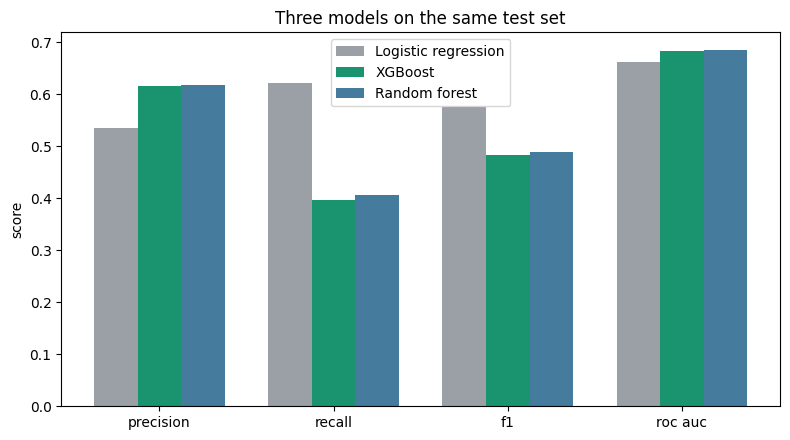

In [6]:
metrics = ["precision", "recall", "f1", "roc auc"]
x = np.arange(len(metrics))
width = 0.25
colors = ["#9aa0a6", "#1a936f", "#457b9d"]

fig, ax = plt.subplots(figsize=(8, 4.5))
for i, row in model_compare.iterrows():
    ax.bar(x + (i - 1) * width, [row[m] for m in metrics], width, label=row["model"], color=colors[i])
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylabel("score")
ax.set_title("Three models on the same test set")
ax.legend()
plt.tight_layout()
plt.show()


## Neighborhoods

To see whether the model treats every neighborhood the same, Chicago census tracts were grouped into a small number of neighborhood types. The method follows a published approach for describing neighborhoods from many small attributes at once.

Each tract carries dozens of measures, things like income, race, health outcomes, and housing. Similar tracts get grouped into fifty small clusters first, then those fifty clusters get merged step by step into a tree. The number of final groups is chosen by a score that checks how cleanly separated the groups are, and that score picked three groups for Chicago.

The three groups line up with real differences in the city. Group one is mostly affluent and mostly white. Group two is Latino and immigrant. Group three is Black with a higher health burden, including higher rates of asthma and lung disease. The map and the profile chart below come straight from that clustering step.


,group,size,high,low
0,1,311,college18 (+1.0); whiteP18 (+0.9); mdHome18 (+...,CEJI (-1.0); socvlnIndx (-0.9); physRt17 (-0.9)
1,2,197,hispP18 (+1.4); other18 (+1.3); frgnBrn18 (+1.0),cancerRt17 (-1.0); lungCRt17 (-0.8); blackP18 ...
2,3,293,blackP18 (+1.2); chAsthma17 (+0.9); lungCRt17 ...,whiteP18 (-1.1); frgnBrn18 (-0.8); college18 (...


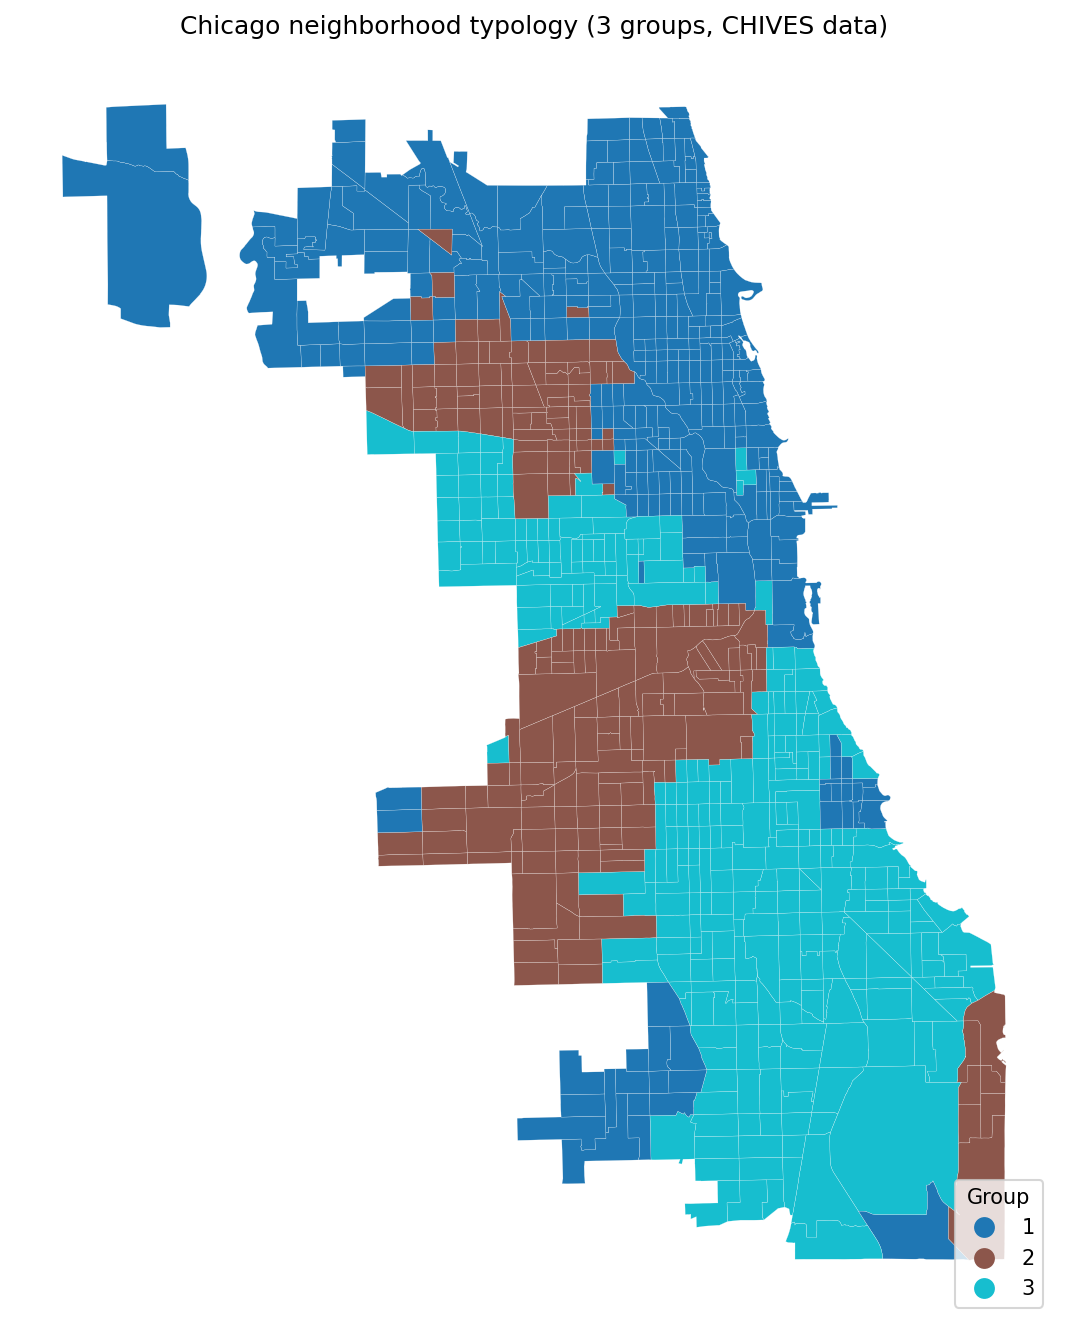

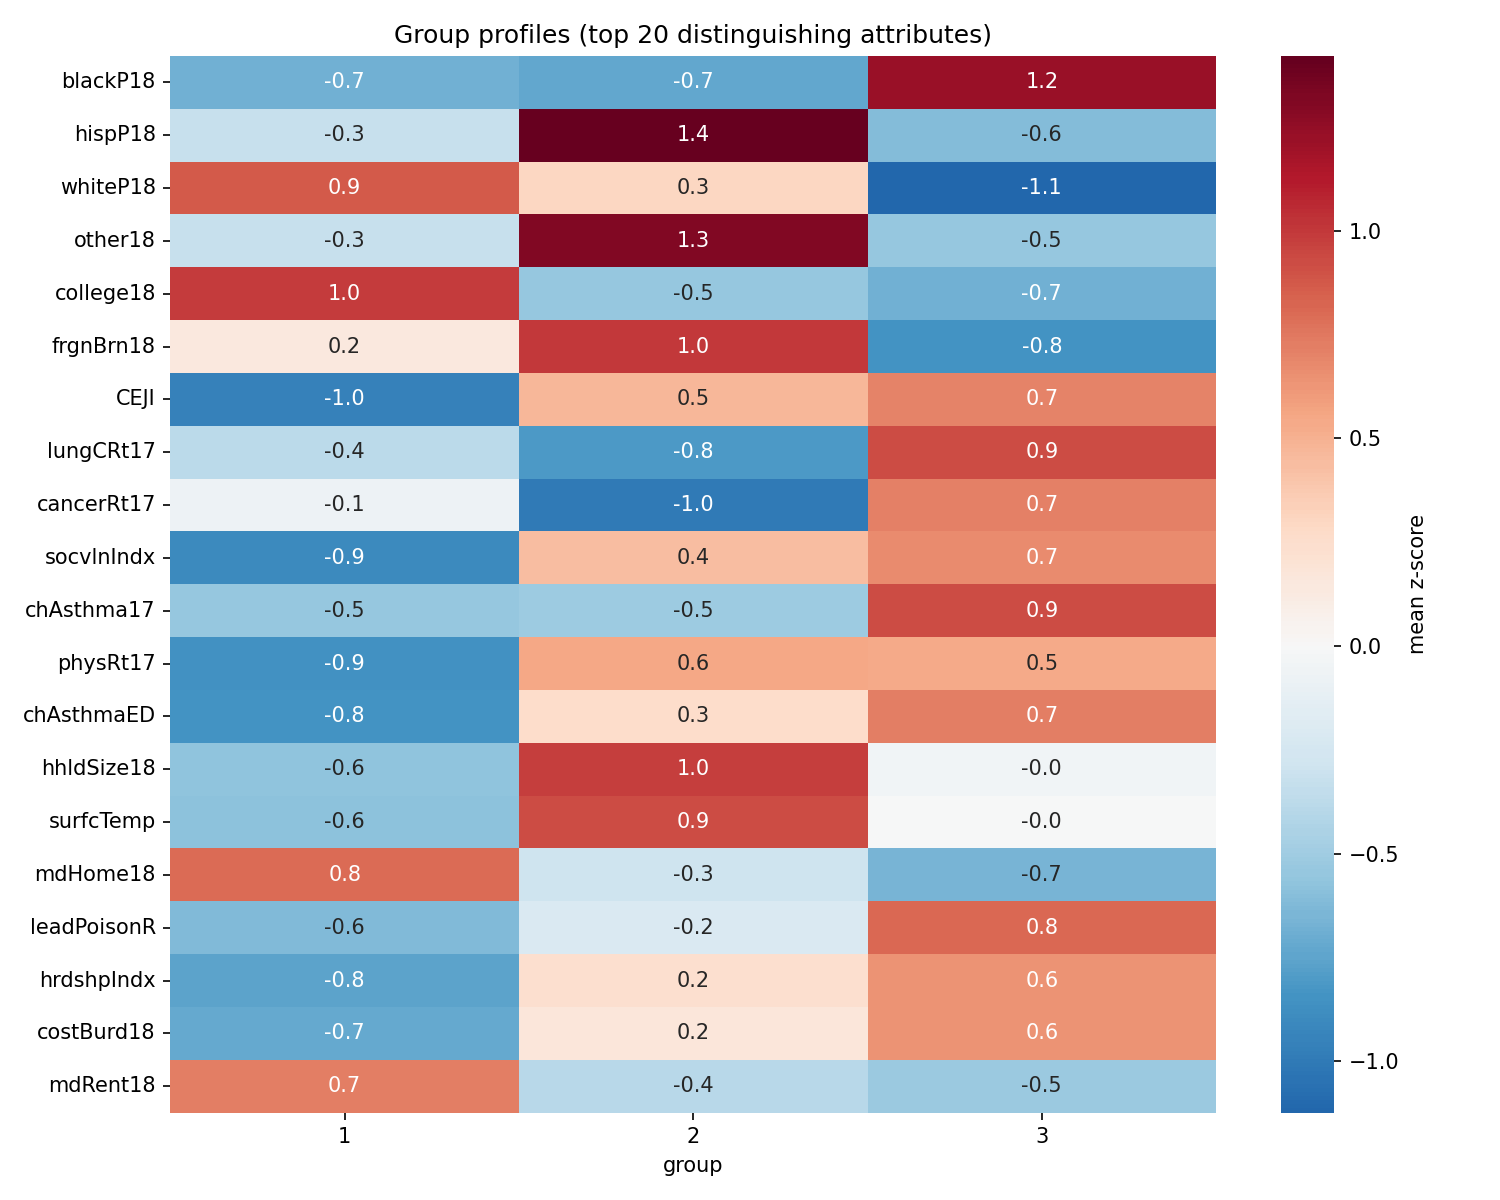

In [7]:
group_summary = pd.read_csv("../REPORTS/typology/group_summary.csv")
display(group_summary)
display(Image("../REPORTS/typology/typology_map.png"))
display(Image("../REPORTS/typology/group_profiles.png"))


Every model above was already scored inside each of the three neighborhood groups, using the same test rows. The table below reads those scores back in.

Recall is the share of the real critical violations that a model actually catches. In the affluent group recall is consistently lower than in the other two groups, across all three models. That is a real and repeated gap, not noise from one model or one run.

From here on this notebook uses one number to track that gap. It is the difference between the best group recall and the worst group recall, and it is called the bias score for the rest of this notebook. A bias score of zero means every neighborhood is caught at the same rate. The cell below prints the bias score for the stock XGBoost model, the one the rest of this notebook builds on.


,model,typology,type,n,precision,recall,f1,support
0,glmnet,1,"Affluent, mostly-white",5445,0.551,0.321,0.406,2162
1,glmnet,2,Latino / immigrant,1786,0.649,0.446,0.528,754
2,glmnet,3,"Black, high health burden",1081,0.599,0.477,0.531,463
3,xgboost,1,"Affluent, mostly-white",5445,0.600,0.351,0.443,2162
4,xgboost,2,Latino / immigrant,1786,0.647,0.479,0.550,754
5,xgboost,3,"Black, high health burden",1081,0.628,0.477,0.542,463
6,random forest,1,"Affluent, mostly-white",5445,0.595,0.378,0.462,2162
7,random forest,2,Latino / immigrant,1786,0.657,0.467,0.546,754
8,random forest,3,"Black, high health burden",1081,0.600,0.486,0.537,463


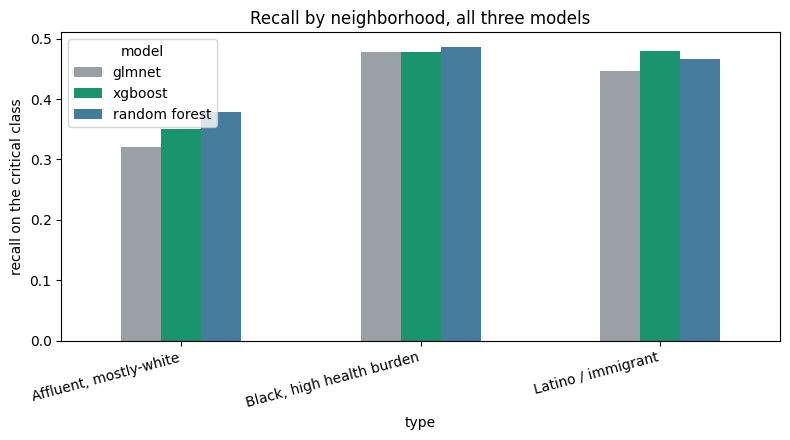

xgboost bias score = 0.128


In [8]:
baseline = pd.read_csv("../../data/42_test_split_typology_baseline.csv")
display(baseline)

pivot = baseline.pivot(index="type", columns="model", values="recall")
pivot = pivot[["glmnet", "xgboost", "random forest"]]

fig, ax = plt.subplots(figsize=(8, 4.5))
pivot.plot(kind="bar", ax=ax, color=["#9aa0a6", "#1a936f", "#457b9d"])
ax.set_ylabel("recall on the critical class")
ax.set_title("Recall by neighborhood, all three models")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()

xgb_rows = baseline[baseline["model"] == "xgboost"]
gap = xgb_rows["recall"].max() - xgb_rows["recall"].min()
print(f"xgboost bias score = {gap:.3f}")


One question comes before any fix. Is the gap about where the cutoff sits, or is it about how well the model can rank restaurants inside each group in the first place.

ROC AUC answers that question, since it measures ranking quality on its own, no cutoff involved. The cell below computes it for the XGBoost model above, separately for each neighborhood.


In [9]:
group_p8 = assign_typology(X_test)
label_map = {1: "Affluent, mostly-white", 2: "Latino / immigrant", 3: "Black, high health burden"}
xgb_proba = xgb_pipe.predict_proba(X_test)[:, 1]

auc_rows = []
for g in (1, 2, 3):
    m = (group_p8 == g).to_numpy()
    auc_rows.append({
        "neighborhood": label_map[g],
        "n": int(m.sum()),
        "roc auc": round(roc_auc_score(y_test[m], xgb_proba[m]), 3),
    })
auc_table = pd.DataFrame(auc_rows)
auc_table


C:\Users\shanm\AppData\Roaming\Python\Python314\site-packages\geopandas\io\file.py:576: UserWarning: Could not parse column 'dsplcPresr' as JSON; leaving as string
  return pyogrio.read_dataframe(path_or_bytes, bbox=bbox, **kwargs)
C:\Users\shanm\AppData\Roaming\Python\Python314\site-packages\geopandas\io\file.py:576: UserWarning: Could not parse column 'physRt17' as JSON; leaving as string
  return pyogrio.read_dataframe(path_or_bytes, bbox=bbox, **kwargs)
C:\Users\shanm\AppData\Roaming\Python\Python314\site-packages\geopandas\io\file.py:576: UserWarning: Could not parse column 'adAsthma17' as JSON; leaving as string
  return pyogrio.read_dataframe(path_or_bytes, bbox=bbox, **kwargs)
C:\Users\shanm\AppData\Roaming\Python\Python314\site-packages\geopandas\io\file.py:576: UserWarning: Could not parse column 'hyptRt17' as JSON; leaving as string
  return pyogrio.read_dataframe(path_or_bytes, bbox=bbox, **kwargs)


,neighborhood,n,roc auc
0,"Affluent, mostly-white",5445,0.667
1,Latino / immigrant,1786,0.724
2,"Black, high health burden",1081,0.692


AUC is lower in the affluent group than in the other two. That gap in ranking quality, not the training weights, is the root of the recall gap. It is also why some fixes below work and others do not. A fix that only nudges the loss function cannot repair a ranking problem on its own, but a fix that sets a different cutoff per group can.


## Fixes

The gap already traces back to weaker ranking in the affluent group, not to the cutoff. Two fixes are tried below. Every fix is judged with the exact same bias score.

The cell below rebuilds the same split and neighborhood groups used above, this time paired with the model's raw prediction scores instead of just a class label.


In [10]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report
from xgboost import XGBClassifier

from model_utils import (
    load_features,
    make_preprocessor,
    assign_typology,
    cost_group_dro_obj,
)

X, y = load_features()
feat_cols = list(X.columns)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# neighborhood group of every row (unknown tracts come back NaN)
g_train = assign_typology(X_train).to_numpy()
X_test = X_test.assign(typology=assign_typology(X_test).values)

matched = X_test["typology"].notna()
test = X_test[matched].copy()
test["typology"] = test["typology"].astype(int)
y_te = y_test.loc[test.index].to_numpy()
grp = test["typology"].to_numpy()

labels = {1: "Affluent, mostly-white", 2: "Latino / immigrant", 3: "Black, high health burden"}
XGB = dict(n_estimators=400, max_depth=5, learning_rate=0.05,
           subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1)

print(f"{len(test)} test rows matched a tract")
print(pd.Series(grp).map(labels).value_counts())

8312 test rows matched a tract
Affluent, mostly-white       5445
Latino / immigrant           1786
Black, high health burden    1081
Name: count, dtype: int64


For each group, recall is the share of the real critical violations that the model actually catches. A fair model catches the same share in every neighborhood. The bias score is the gap between the best group and the worst group. A gap of zero means perfect fairness and a bigger gap means more bias. This is the same definition used in the bias paper.

The helper below also reports precision, recall, F1, and support for every group, so the cost of each fix stays visible.


In [11]:
def fit_scores(objective=None, sample_weight=None):
    """Train an XGBoost pipeline and return its predicted probability on the test set."""
    est = XGBClassifier(objective=objective, **XGB) if objective else XGBClassifier(eval_metric="logloss", **XGB)
    pipe = Pipeline([("prep", make_preprocessor()), ("model", est)])
    fit_kw = {"model__sample_weight": sample_weight} if sample_weight is not None else {}
    pipe.fit(X_train, y_train, **fit_kw)
    prep, model = pipe.named_steps["prep"], pipe.named_steps["model"]
    if objective:  # custom objective emits raw margins, so sigmoid them ourselves
        margin = model.predict(prep.transform(test[feat_cols]), output_margin=True)
        return 1.0 / (1.0 + np.exp(-margin))
    return pipe.predict_proba(test[feat_cols])[:, 1]


def per_group_report(pred):
    """Precision, recall, F1, and support for the critical class, per neighborhood."""
    rows = []
    for g in (1, 2, 3):
        m = grp == g
        rep = classification_report(y_te[m], pred[m], labels=[0, 1],
                                    output_dict=True, zero_division=0)["1"]
        rows.append({"typology": g, "type": labels[g], "n": int(m.sum()),
                     "precision": round(rep["precision"], 3), "recall": round(rep["recall"], 3),
                     "f1": round(rep["f1-score"], 3), "support": int(rep["support"])})
    return pd.DataFrame(rows)


def eod(pred):
    """Bias score: max minus min per-group recall on the critical class."""
    rec = {}
    for g in (1, 2, 3):
        m = (grp == g) & (y_te == 1)
        rec[g] = pred[m].sum() / m.sum()
    return max(rec.values()) - min(rec.values())

First an ordinary XGBoost model gets trained with no fix at all. This is the baseline everything else is compared against.


In [12]:
stock = fit_scores()
stock_pred = (stock >= 0.5).astype(int)

print(f"bias score (recall gap) = {eod(stock_pred):.3f}")
print(f"inspections flagged = {stock_pred.mean() * 100:.0f}%")
per_group_report(stock_pred)

bias score (recall gap) = 0.128
inspections flagged = 26%


,typology,type,n,precision,recall,f1,support
0,1,"Affluent, mostly-white",5445,0.600,0.351,0.443,2162
1,2,Latino / immigrant,1786,0.647,0.479,0.550,754
2,3,"Black, high health burden",1081,0.628,0.477,0.542,463


The first fix builds the correction into the training itself. The custom loss does two things. It treats a missed violation as three times worse than a false alarm, and every round it pushes hardest on whichever neighborhood the model is currently worst at. The group weighting idea comes from the group robustness paper.

This lifts recall in every neighborhood, but it does so by flagging far more inspections than before, so the gain is not free.


In [13]:
cust = fit_scores(objective=cost_group_dro_obj(g_train, cost_ratio=3.0, eta=3.0))
cust_pred = (cust >= 0.5).astype(int)

print(f"bias score (recall gap) = {eod(cust_pred):.3f}")
print(f"inspections flagged = {cust_pred.mean() * 100:.0f}%")
per_group_report(cust_pred)

bias score (recall gap) = 0.013
inspections flagged = 81%


,typology,type,n,precision,recall,f1,support
0,1,"Affluent, mostly-white",5445,0.433,0.905,0.585,2162
1,2,Latino / immigrant,1786,0.492,0.891,0.634,754
2,3,"Black, high health burden",1081,0.477,0.901,0.624,463


The second fix comes from the bias paper and it happens after the model is trained. Instead of using one cutoff for everyone, a separate cutoff gets chosen for each neighborhood so that every group reaches the same recall. The model and its scores never change. Only the decision line moves.


In [14]:
def group_thresholds(scores, target_recall):
    """Per-group cutoff that makes each group reach target_recall on the critical class."""
    thr = {}
    for g in (1, 2, 3):
        pos = scores[(grp == g) & (y_te == 1)]
        thr[g] = np.quantile(pos, 1 - target_recall)
    return thr


def apply_group_thresholds(scores, thr):
    pred = np.zeros_like(scores, dtype=int)
    for g in (1, 2, 3):
        m = grp == g
        pred[m] = (scores[m] >= thr[g]).astype(int)
    return pred


# aim every group at the plain model's own overall recall
target = stock_pred[y_te == 1].mean()
post_pred = apply_group_thresholds(stock, group_thresholds(stock, target))

print(f"target recall for every group = {target:.3f}")
print(f"bias score (recall gap) = {eod(post_pred):.3f}")
print(f"inspections flagged = {post_pred.mean() * 100:.0f}%")
per_group_report(post_pred)

target recall for every group = 0.397
bias score (recall gap) = 0.001
inspections flagged = 26%


,typology,type,n,precision,recall,f1,support
0,1,"Affluent, mostly-white",5445,0.585,0.397,0.473,2162
1,2,Latino / immigrant,1786,0.697,0.397,0.505,754
2,3,"Black, high health burden",1081,0.687,0.397,0.503,463


The fixes above are each measured at their own natural cutoff, which makes them hard to compare. Here every model is forced to the same overall recall, and the bias score gets read off from there. This is the fair test. If a fix only looked good because it flagged more inspections, that advantage disappears here.

The result is the main point of this notebook. Changing the loss barely moves the bias score, because the unfairness lives in the scores the model produces. Only the after training cutoff adjustment brings the gap close to zero, and by a wide margin it is the fix that reduces bias the most.


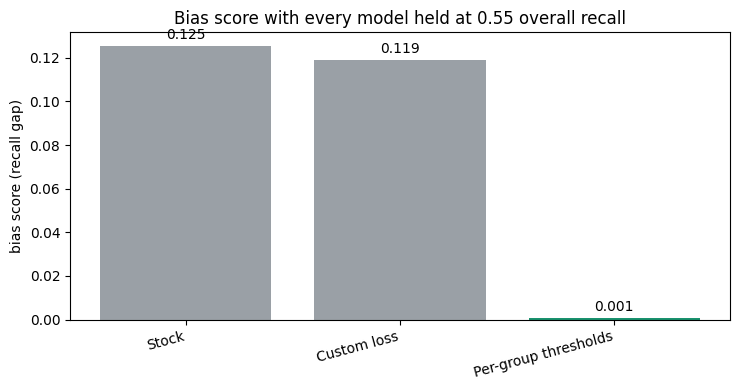

,method,bias score
0,Stock,0.125
1,Custom loss,0.119
2,Per-group thresholds,0.001


In [15]:
def global_threshold_pred(scores, target_recall):
    """One cutoff for everyone, set so overall recall equals target_recall."""
    thr = np.quantile(scores[y_te == 1], 1 - target_recall)
    return (scores >= thr).astype(int)


T = 0.55  # common overall recall for every arm
arms = {
    "Stock": global_threshold_pred(stock, T),
    "Custom loss": global_threshold_pred(cust, T),
    "Per-group thresholds": apply_group_thresholds(stock, group_thresholds(stock, T)),
}

names = list(arms)
eods = [eod(arms[n]) for n in names]
colors = ["#9aa0a6", "#9aa0a6", "#1a936f"]

fig, ax = plt.subplots(figsize=(7.5, 4))
ax.bar(names, eods, color=colors)
ax.set_ylabel("bias score (recall gap)")
ax.set_title(f"Bias score with every model held at {T:.2f} overall recall")
for i, v in enumerate(eods):
    ax.text(i, v + 0.002, f"{v:.3f}", ha="center", va="bottom")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()

pd.DataFrame({"method": names, "bias score": [round(e, 3) for e in eods]})


## Results

The table below pulls together every fix tried above, at a fair operating point for each. Every arm is held to the same overall recall, fifty five percent, so the comparison is not distorted by one fix simply flagging more inspections.

Reading the after column against the before column is the whole story of this notebook in one place.


In [16]:
stock_gap = eod(arms["Stock"])

summary_rows = []
for name, pred in arms.items():
    val = eod(pred)
    summary_rows.append({
        "method": name,
        "operating point": f"{T:.2f} overall recall for every arm",
        "bias score before": round(stock_gap, 3),
        "bias score after": round(val, 3),
        "change": round(val - stock_gap, 3),
        "percent reduced": round((stock_gap - val) / stock_gap * 100, 0) if stock_gap else 0.0,
        "overall recall": round(pred[y_te == 1].mean(), 3),
        "flagged": round(pred.mean(), 3),
    })

results_summary = pd.DataFrame(summary_rows)
results_summary


,method,operating point,bias score before,bias score after,change,percent reduced,overall recall,flagged
0,Stock,0.55 overall recall for every arm,0.125,0.125,0.000,0.0,0.55,0.397
1,Custom loss,0.55 overall recall for every arm,0.125,0.119,-0.007,5.0,0.55,0.396
2,Per-group thresholds,0.55 overall recall for every arm,0.125,0.001,-0.125,99.0,0.55,0.397


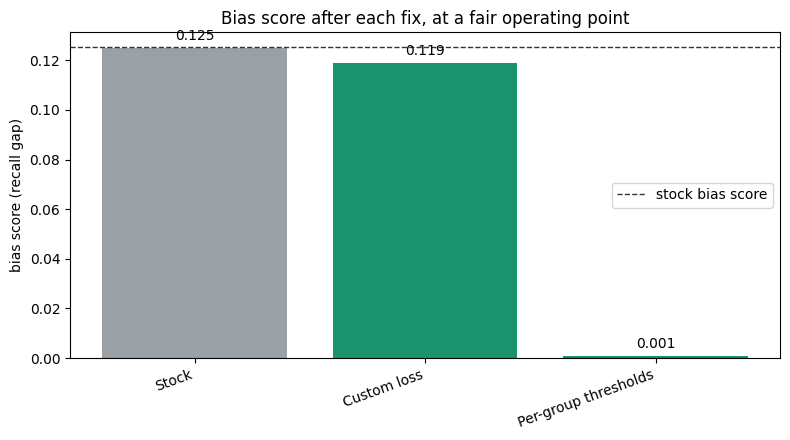

In [17]:
bar_colors = []
for _, r in results_summary.iterrows():
    if r["method"] == "Stock":
        bar_colors.append("#9aa0a6")
    elif r["bias score after"] < r["bias score before"]:
        bar_colors.append("#1a936f")
    else:
        bar_colors.append("#e63946")

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(results_summary["method"], results_summary["bias score after"], color=bar_colors)
ax.axhline(stock_gap, color="#333333", linestyle="dashed", linewidth=1, label="stock bias score")
ax.set_ylabel("bias score (recall gap)")
ax.set_title("Bias score after each fix, at a fair operating point")
for i, v in enumerate(results_summary["bias score after"]):
    ax.text(i, v + 0.002, f"{v:.3f}", ha="center", va="bottom")
plt.xticks(rotation=20, ha="right")
plt.legend()
plt.tight_layout()
plt.show()


Step back and look at the whole arc. Raw city data got cleaned, turned into features, and used to train three kinds of models. XGBoost won on every metric, and once it was scored inside three kinds of Chicago neighborhoods a real gap showed up. The model was less able to rank restaurants correctly in the affluent group, and that ranking weakness is the actual source of the bias, not the training weights.

Changing the loss during training barely closes that gap, because it only changes how errors get penalized, not the ranking problem underneath. The fix that actually works is setting a separate cutoff for each neighborhood after training. It drives the gap close to zero, and out of everything tried here it reduces bias by far the most, at the price of using the neighborhood label at the moment the decision is made.

Even this real fix is not a free win. It closes the gap by lowering the strong neighborhoods rather than lifting the weak one, and because the weakest neighborhood here is the affluent one, that means catching fewer violations in the higher health burden areas. A smaller gap is not automatically a better outcome, and the table above shows exactly what this fix actually cost.

So yes, bias in this model can be reduced, and per group thresholds are what actually does it, with real numbers behind the claim. The broader lesson is that fairness is not one knob. It can be handled during training or after training, and the right choice depends on where the bias lives and which cost is worth paying.

### References

Sagawa, Shiori, Pang Wei Koh, Tatsunori B. Hashimoto, and Percy Liang. "Distributionally Robust Neural Networks for Group Shifts: On the Importance of Regularization for Worst-Case Generalization." In International Conference on Learning Representations. 2020. arXiv 1911.08731.

Hardt, Moritz, Eric Price, and Nathan Srebro. "Equality of Opportunity in Supervised Learning." In Advances in Neural Information Processing Systems. 2016. arXiv 1610.02413.

Spielman, Seth E., and Alex Singleton. "Studying Neighborhoods Using Uncertain Data from the American Community Survey, A Contextual Approach." Annals of the Association of American Geographers 105, no. 5 (2015), 1003 to 1025.
